In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

iat_df = pd.read_csv('data/processed_IAT_data_n80.csv')
pat_df = pd.read_csv('data/pat_diffes_with_accuracy_2024-08-20.csv')
iat_cols = iat_df.columns
pat_cols = pat_df.columns
print(iat_cols)

Index(['participant', 'gender', 'age', 'expName', 'date',
       'critical_blocks_percentage_accuracy', 'critical_blocks_mean_rt',
       'exclude_based_on_fast_trials', 'IAT_D1', 'IAT_D1a', 'IAT_D1b'],
      dtype='object')


In [76]:
def clean_iat_gender(iat_df):
    for i, row in enumerate(iat_df['gender']):
        print(row)
        if row.lower() in ['female', 'Female', 'F', 'f', 'woman']:
            iat_df['gender'].iloc[i] = "F"
        if row.lower() in ['male', 'Male', 'M', 'm']:
            iat_df['gender'].iloc[i] = "M"
        
clean_iat_gender(iat_df)

merged = iat_df.merge(pat_df, left_on='participant', right_on='pat_id')


nonbinary
female
female
Male
Female
female
male
female
female
Female
Male
male
female
M
F
F
female
M
F
female
female
female
male
female
male
woman
female
female
male
female
female
female
nonbinary
female
female
male
female
female
female
male
male
transwoman
female
female
agender
female
male
Male
female
female
female
female
female
female
nonbinary
nonbinary
female
female
male
female
male
female
male
male
female
male
female
female
male
male
female
female
female
female
female
male


/var/folders/15/_7jw71x17_nd9f6wldr33w8r0000gn/T/ipykernel_4913/541147026.py:5: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  iat_df['gender'].iloc[i] = "F"
/var/folders/15/_7jw71x17_nd9f6wldr33w8r0000gn/T/ipykernel_4913/541147026.py:5: Sett

In [77]:
print(iat_cols)
print(pat_cols)

Index(['participant', 'gender', 'age', 'expName', 'date',
       'critical_blocks_percentage_accuracy', 'critical_blocks_mean_rt',
       'exclude_based_on_fast_trials', 'IAT_D1', 'IAT_D1a', 'IAT_D1b'],
      dtype='object')
Index(['Q53', 'pat_id', 'coin positive player coins change',
       'coin positive e1 coins change', 'coin positive e2 coins change',
       'coin positive e3 coins change',
       'coin positive To what extent do you feel happy right now? change',
       'coin positive Confident? change', 'coin positive Stressed? change',
       'coin positive Excited? change',
       ...
       'speed diff How well are you playing this game right now? change',
       'speed ratio How well are you playing this game right now? change',
       'coin positive player most boolean',
       'coin negative player most boolean',
       'speed positive player most boolean',
       'speed negative player most boolean',
       'coin positive Which player do you think collected the most coins

In [78]:
correct_cols = [col for col in merged.columns if 'correct' in col]
correct_cols
merged['accuracy'] = merged[correct_cols].mean(axis=1)

In [79]:
for col in iat_cols:
    print(col)
    print(iat_df[col].unique())
    print(iat_df[col].value_counts())

participant
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 23 24 25 26
 27 28 29 30 31 39 40 41 42 43 44 46 47 48 49 50 51 52 53 54 55 56 57 58
 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 22 32
 33 34 36 38]
participant
1     1
59    1
66    1
65    1
64    1
     ..
27    1
26    1
25    1
24    1
38    1
Name: count, Length: 76, dtype: int64
gender
['nonbinary' 'F' 'M' 'transwoman' 'agender']
gender
F             48
M             22
nonbinary      4
transwoman     1
agender        1
Name: count, dtype: int64
age
[27 23 24 28 30 22 26 25 21 29]
age
22    12
21    11
23     9
26     9
27     7
25     7
28     6
30     6
29     6
24     3
Name: count, dtype: int64
expName
['IAT']
expName
IAT    76
Name: count, dtype: int64
date
['2022-09-14_15h22.33.914' '2022-09-23_10h02.06.696'
 '2022-09-28_16h04.45.231' '2022-09-30_09h16.37.327'
 '2022-10-03_10h12.21.115' '2022-10-12_16h45.16.296'
 '2022-10-14_11h07.54.689' '2022-10-19_16h10.44.099'
 '2022-10-26_1

<Axes: xlabel='IAT_D1', ylabel='accuracy'>

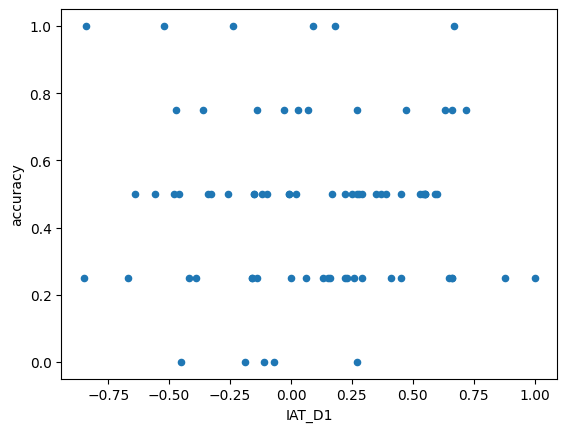

In [80]:
merged[['IAT_D1','accuracy']].corr()
merged[['IAT_D1','accuracy']].plot.scatter(x='IAT_D1', y='accuracy')

In [81]:
v1 = merged[merged["pat_id"] < 66]
print(v1["accuracy"].mean())
print(v1["IAT_D1"].mean())
print(v1["IAT_D1"].std())
print(v1["accuracy"].std())
v2 = merged[merged["pat_id"] >= 66]
print(v2["accuracy"].mean())
print(v2["IAT_D1"].mean())
print(v2["IAT_D1"].std())
print(v2["accuracy"].std())

0.4098360655737705
0.05606557377049181
0.43604769879958694
0.23288403268063618
0.7
0.26666666666666666
0.2978414407189231
0.19364916731037085


            IAT_D1  accuracy
IAT_D1    1.000000 -0.112284
accuracy -0.112284  1.000000


<Axes: xlabel='IAT_D1', ylabel='accuracy'>

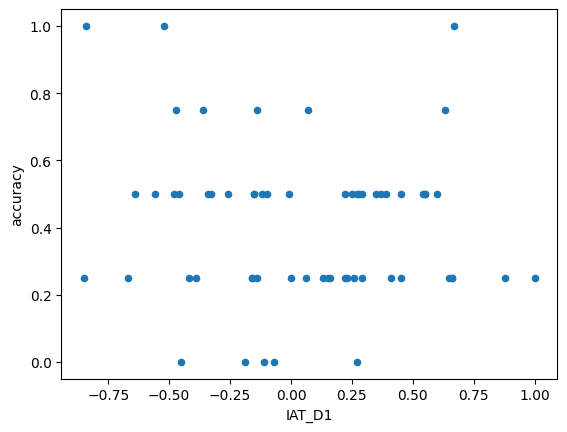

In [82]:
print(v1[['IAT_D1','accuracy']].corr())
v1[['IAT_D1','accuracy']].plot.scatter(x='IAT_D1', y='accuracy')

            IAT_D1  accuracy
IAT_D1    1.000000 -0.315799
accuracy -0.315799  1.000000


<Axes: xlabel='IAT_D1', ylabel='accuracy'>

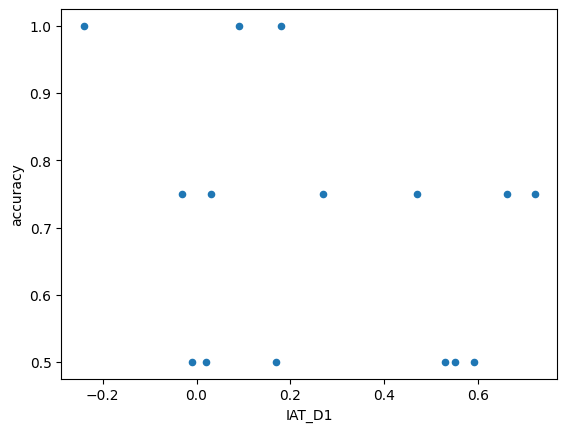

In [83]:
print(v2[['IAT_D1','accuracy']].corr())
v2[['IAT_D1','accuracy']].plot.scatter(x='IAT_D1', y='accuracy')

In [84]:
d_dict = {}
p_dict = {}
for col in pat_cols:
    if v1[col].dtype == 'object':
        continue
    if v1[col].dtype == 'bool':
        continue
    v1_mean = v1[col].mean()
    v2_mean = v2[col].mean()
    v1_std = v1[col].std()
    v2_std = v2[col].std()
    test = scipy.stats.ttest_ind(v1[col], v2[col])
    pval = test.pvalue
    cohens_d = (v1_mean - v2_mean) / np.sqrt((v1_std**2 + v2_std**2) / 2)
    print(f"v1 vs v2 d: {cohens_d} for {col}")
    print(f"v1 vs v2 p: {pval} for {col}")
    p_dict[col] = pval
    d_dict[col] = cohens_d
    
d_df = pd.DataFrame.from_dict(d_dict, orient='index', columns=['d'])
p_df = pd.DataFrame.from_dict(p_dict, orient='index', columns=['p'])
d_df.to_csv('data/v1_v2_d.csv')
p_df.to_csv('data/v1_v2_p_diffs.csv')

v1 vs v2 d: -2.8489824298876676 for pat_id
v1 vs v2 p: 1.8546255864096882e-11 for pat_id
v1 vs v2 d: -0.41536633605941514 for coin positive player coins change
v1 vs v2 p: 0.21033027976008054 for coin positive player coins change
v1 vs v2 d: -0.3137971720361877 for coin positive e1 coins change
v1 vs v2 p: 0.3116308778193434 for coin positive e1 coins change
v1 vs v2 d: -0.15740417118621164 for coin positive e2 coins change
v1 vs v2 p: 0.6154574822315231 for coin positive e2 coins change
v1 vs v2 d: 0.7929363453914587 for coin positive e3 coins change
v1 vs v2 p: 0.007326716597452264 for coin positive e3 coins change
v1 vs v2 d: 0.1369029301011412 for coin positive To what extent do you feel happy right now? change
v1 vs v2 p: 0.6749271982919103 for coin positive To what extent do you feel happy right now? change
v1 vs v2 d: 0.04142968927673437 for coin positive Confident? change
v1 vs v2 p: 0.9040568580266002 for coin positive Confident? change
v1 vs v2 d: 0.359019803223389 for coin p

/Users/lwang/pat-data-processing/.venv/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:573: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
